# Electricity Demand Forecasting
End-to-end time series forecasting project.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap
import json
import os
import sys
sys.path.append("../")
%matplotlib inline

## 1. Load Data & EDA

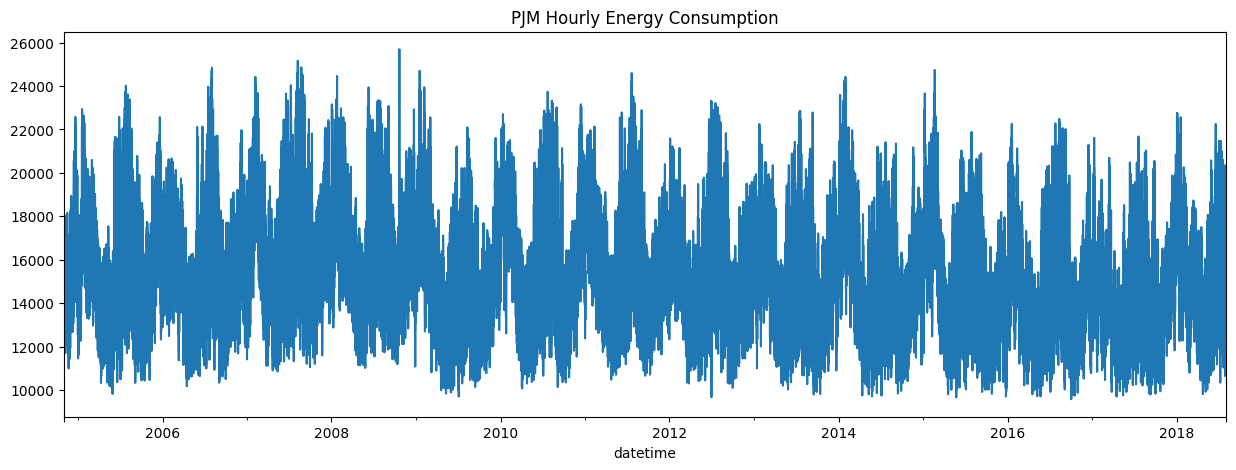

In [2]:
df = pd.read_csv("../data/processed/AEP_hourly_features.csv")
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime')['load_mw'].plot(figsize=(15, 5), title='PJM Hourly Energy Consumption')
plt.show()

## 2. Model Performance Comparison

,MAE,RMSE,MAPE
Prophet,1396.962516,1769.790884,0.090045
XGBoost,125.093756,161.942321,0.008109
LSTM,170.689469,222.046866,0.011098
TFT,896.775848,1060.033854,0.055287


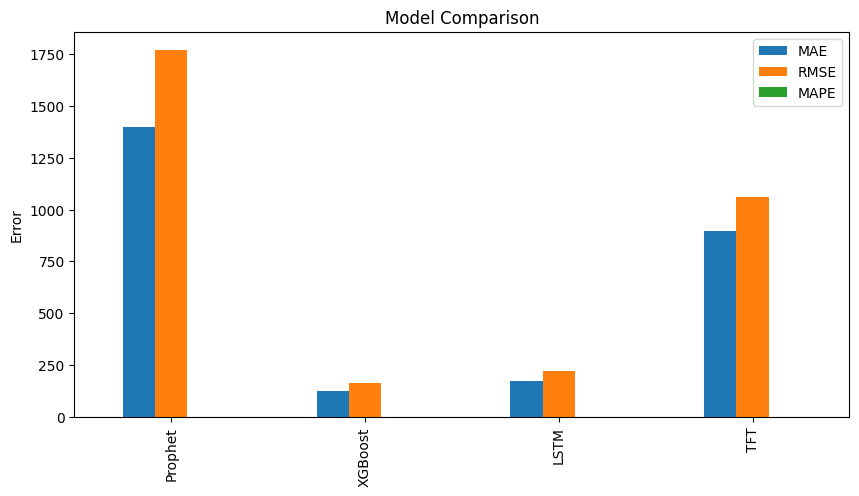

In [3]:
with open("../reports/metrics.json", "r") as f:
    metrics = json.load(f)
metrics_df = pd.DataFrame(metrics).T
display(metrics_df)
metrics_df.plot(kind='bar', figsize=(10, 5), title='Model Comparison')
plt.ylabel('Error')
plt.show()

## 3. SHAP Interpretability (XGBoost)

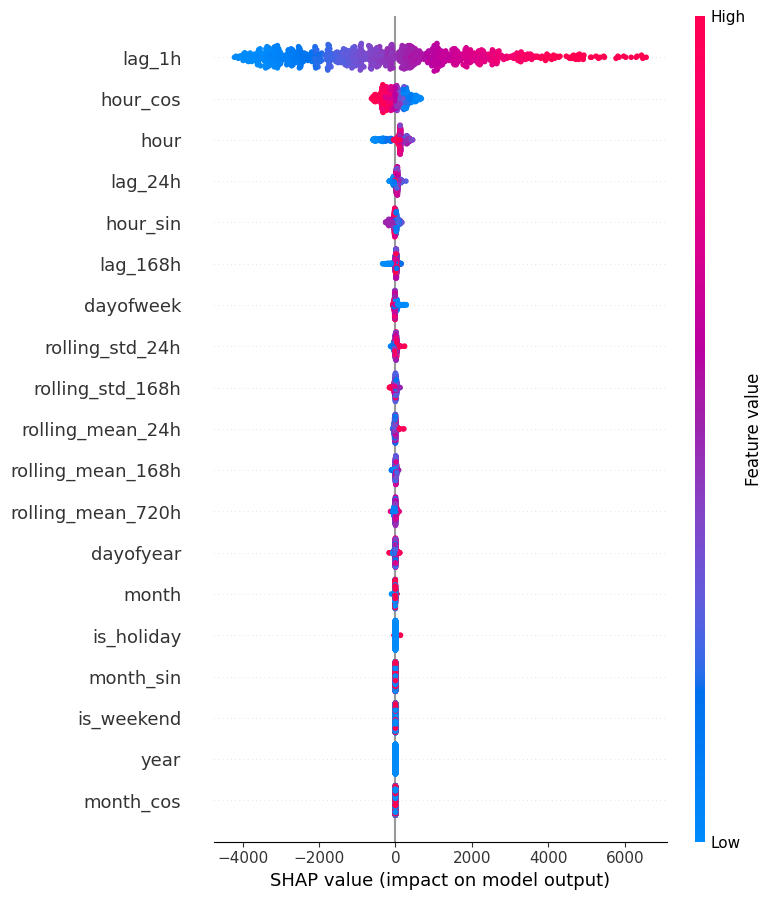

In [4]:
# Train a simple XGBoost on the latest data to extract SHAP values
target = 'load_mw'
features = [c for c in df.columns if c not in ['datetime', target]]
X = df[features].iloc[-2000:-1000]
y = df[target].iloc[-2000:-1000]
model = xgb.XGBRegressor(n_estimators=100, max_depth=5)
model.fit(X, y)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)
shap.summary_plot(shap_values, X)